### 1. Load packages and data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp
from scipy.optimize import least_squares

In [2]:
# Johns Hopkins CSSE historical confirmed cases time series
url = "https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/csse_covid_19_data/csse_covid_19_time_series/time_series_covid19_confirmed_global.csv"

confirmed = pd.read_csv(url)
confirmed.head()

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,2/28/23,3/1/23,3/2/23,3/3/23,3/4/23,3/5/23,3/6/23,3/7/23,3/8/23,3/9/23
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,209322,209340,209358,209362,209369,209390,209406,209436,209451,209451
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,334391,334408,334408,334427,334427,334427,334427,334427,334443,334457
2,NaN,Algeria,28.03390,1.659600,0,0,0,0,0,0,...,271441,271448,271463,271469,271469,271477,271477,271490,271494,271496
3,NaN,Andorra,42.50630,1.521800,0,0,0,0,0,0,...,47866,47875,47875,47875,47875,47875,47875,47875,47890,47890
4,NaN,Angola,-11.20270,17.873900,0,0,0,0,0,0,...,105255,105277,105277,105277,105277,105277,105277,105277,105288,105288


### 2. Select Hubei data

In [3]:
# Select Hubei, China
hubei = confirmed[
    (confirmed["Province/State"] == "Hubei") &
    (confirmed["Country/Region"] == "China")
]

hubei

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,2/28/23,3/1/23,3/2/23,3/3/23,3/4/23,3/5/23,3/6/23,3/7/23,3/8/23,3/9/23
72,Hubei,China,30.9756,112.2707,444,444,549,761,1058,1423,...,72131,72131,72131,72131,72131,72131,72131,72131,72131,72131


In [4]:
# Convert wide date columns into long format
date_cols = hubei.columns[4:]

hubei_long = hubei[date_cols].T.reset_index()
hubei_long.columns = ["date", "confirmed"]
hubei_long["date"] = pd.to_datetime(hubei_long["date"])
hubei_long["confirmed"] = hubei_long["confirmed"].astype(float)

hubei_long.head()

/var/folders/qr/gqb3xtc146dbfzn88t01pr1c0000gn/T/ipykernel_69179/1368542346.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  hubei_long["date"] = pd.to_datetime(hubei_long["date"])


,date,confirmed
0,2020-01-22,444.0
1,2020-01-23,444.0
2,2020-01-24,549.0
3,2020-01-25,761.0
4,2020-01-26,1058.0


### 3. Choose first-wave period

In [5]:
start_date = "2020-01-22"
end_date = "2020-04-30"

df = hubei_long[
    (hubei_long["date"] >= start_date) &
    (hubei_long["date"] <= end_date)
].copy()

df["days"] = (df["date"] - df["date"].iloc[0]).dt.days
df["new_cases"] = df["confirmed"].diff().fillna(0)

df.head()

,date,confirmed,days,new_cases
0,2020-01-22,444.0,0,0.0
1,2020-01-23,444.0,1,0.0
2,2020-01-24,549.0,2,105.0
3,2020-01-25,761.0,3,212.0
4,2020-01-26,1058.0,4,297.0


### 4. Plot observed Hubei data

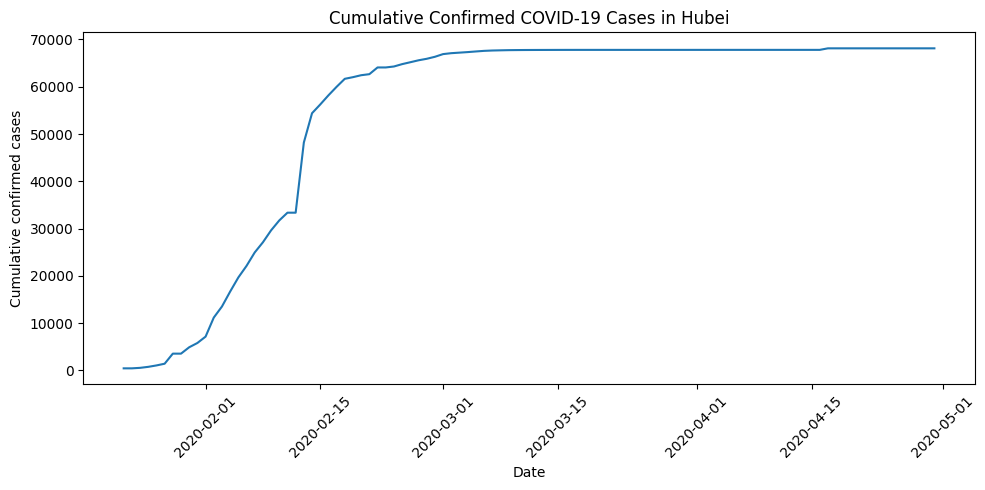

In [6]:
plt.figure(figsize=(10, 5))
plt.plot(df["date"], df["confirmed"])
plt.xlabel("Date")
plt.ylabel("Cumulative confirmed cases")
plt.title("Cumulative Confirmed COVID-19 Cases in Hubei")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

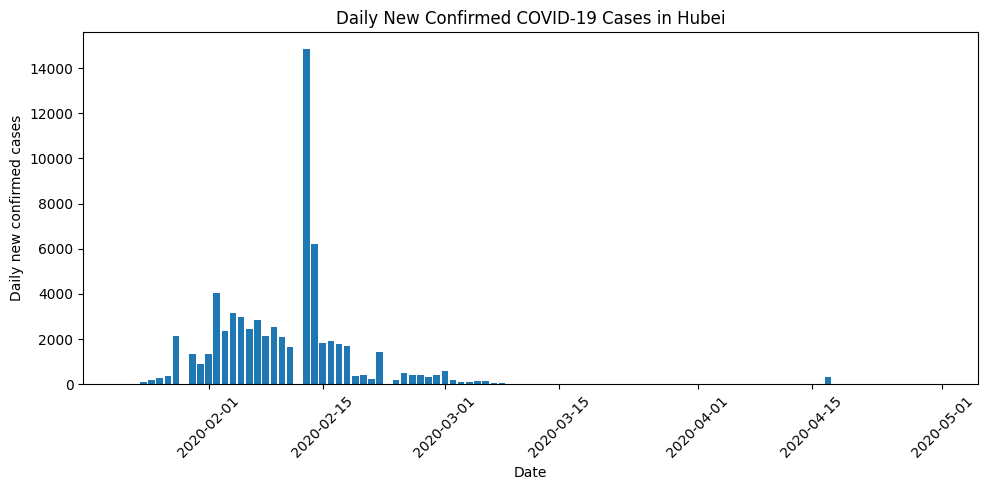

In [7]:
plt.figure(figsize=(10, 5))
plt.bar(df["date"], df["new_cases"])
plt.xlabel("Date")
plt.ylabel("Daily new confirmed cases")
plt.title("Daily New Confirmed COVID-19 Cases in Hubei")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 5. Define the SIR model

In [8]:
def sir_model(t, y, beta, gamma, N):
    S, I, R = y
    
    dSdt = -beta * S * I / N
    dIdt = beta * S * I / N - gamma * I
    dRdt = gamma * I
    
    return [dSdt, dIdt, dRdt]

### 6. Fit SIR model to Hubei cumulative cases

In [9]:
t_data = df["days"].values
observed_cumulative = df["confirmed"].values

I0 = observed_cumulative[0]
R0_initial = 0

def simulate_cumulative_cases(beta, gamma, N_eff, t_eval):
    S0 = N_eff - I0 - R0_initial
    y0 = [S0, I0, R0_initial]
    
    sol = solve_ivp(
        fun=lambda t, y: sir_model(t, y, beta, gamma, N_eff),
        t_span=(t_eval[0], t_eval[-1]),
        y0=y0,
        t_eval=t_eval,
        max_step=1
    )
    
    S = sol.y[0]
    cumulative_cases = N_eff - S
    
    return cumulative_cases

In [10]:
def residuals(params):
    beta, gamma, N_eff = params
    
    model_cumulative = simulate_cumulative_cases(beta, gamma, N_eff, t_data)
    
    # Scale residuals to make optimization more stable
    return (model_cumulative - observed_cumulative) / observed_cumulative.max()

In [11]:
# Initial guesses
beta_guess = 0.35
gamma_guess = 0.10
N_eff_guess = observed_cumulative.max() * 2

# Bounds
lower_bounds = [0.01, 0.01, observed_cumulative.max() * 1.01]
upper_bounds = [2.00, 1.00, 5_000_000]

fit = least_squares(
    residuals,
    x0=[beta_guess, gamma_guess, N_eff_guess],
    bounds=(lower_bounds, upper_bounds)
)

beta_fit, gamma_fit, N_eff_fit = fit.x

beta_fit, gamma_fit, N_eff_fit

(0.3288396443607881, 0.065299253701926, 68809.28000184208)

### 7. Plot fitted SIR curve vs observed data

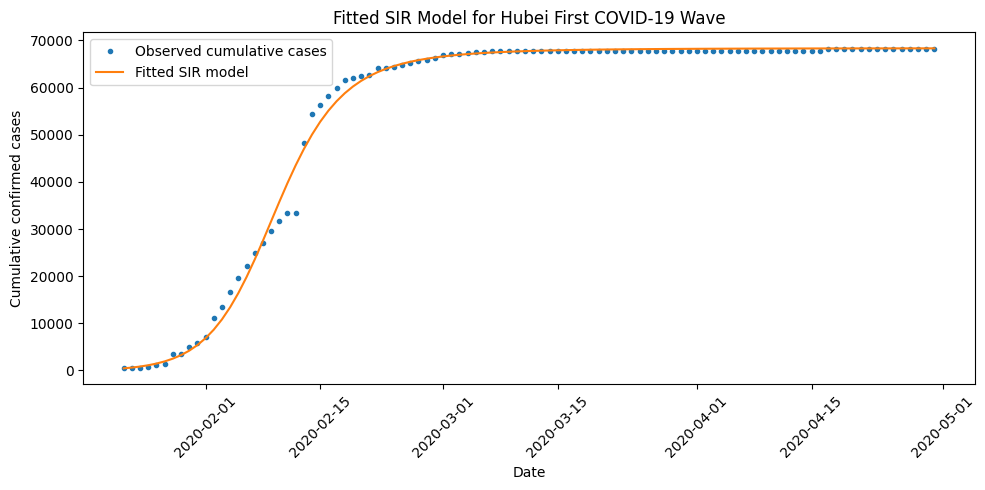

In [12]:
fitted_cumulative = simulate_cumulative_cases(beta_fit, gamma_fit, N_eff_fit, t_data)

plt.figure(figsize=(10, 5))
plt.plot(df["date"], observed_cumulative, "o", markersize=3, label="Observed cumulative cases")
plt.plot(df["date"], fitted_cumulative, label="Fitted SIR model")
plt.xlabel("Date")
plt.ylabel("Cumulative confirmed cases")
plt.title("Fitted SIR Model for Hubei First COVID-19 Wave")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

### 8. Counterfactual: reduce transmission rate

In [13]:
def simulate_full_sir(beta, gamma, N_eff, t_eval):
    S0 = N_eff - I0 - R0_initial
    y0 = [S0, I0, R0_initial]
    
    sol = solve_ivp(
        fun=lambda t, y: sir_model(t, y, beta, gamma, N_eff),
        t_span=(t_eval[0], t_eval[-1]),
        y0=y0,
        t_eval=t_eval,
        max_step=1
    )
    
    S, I, R = sol.y
    cumulative_cases = N_eff - S
    daily_new_cases = beta * S * I / N_eff
    
    return S, I, R, cumulative_cases, daily_new_cases


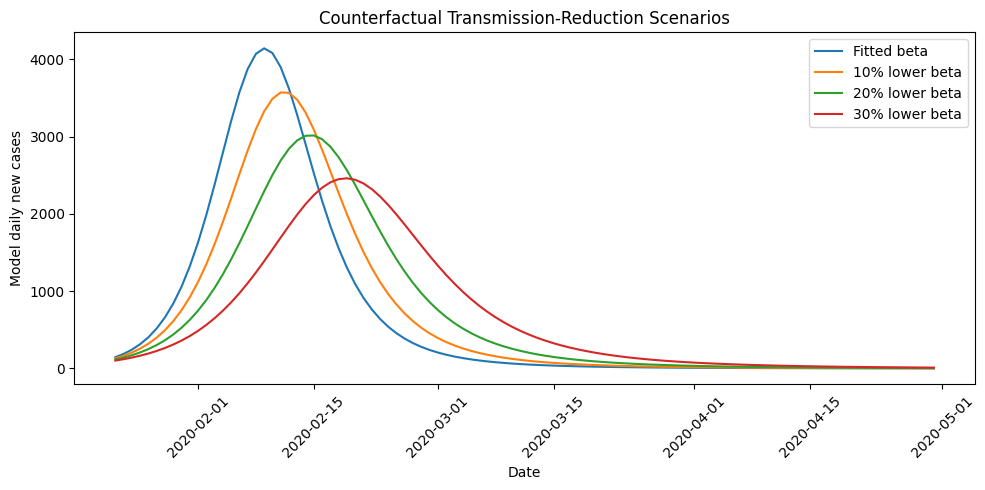

,Scenario,Beta,Peak daily cases,Peak date,Final cumulative cases
0,Fitted beta,0.328840,4141.213135,2020-02-09,68332.455809
1,10% lower beta,0.295956,3570.995457,2020-02-11,68001.180940
2,20% lower beta,0.263072,3014.090000,2020-02-15,67421.063758
3,30% lower beta,0.230188,2459.837362,2020-02-19,66369.143732


In [14]:
scenarios = {
    "Fitted beta": 1.0,
    "10% lower beta": 0.9,
    "20% lower beta": 0.8,
    "30% lower beta": 0.7
}

results = []
counterfactual_curves = {}

plt.figure(figsize=(10, 5))

for label, multiplier in scenarios.items():
    beta_scenario = beta_fit * multiplier
    
    S, I, R, cumulative_cases, daily_new_cases = simulate_full_sir(
        beta_scenario,
        gamma_fit,
        N_eff_fit,
        t_data
    )
    
    peak_cases = daily_new_cases.max()
    peak_day_index = daily_new_cases.argmax()
    peak_date = df["date"].iloc[peak_day_index]
    final_cumulative = cumulative_cases[-1]
    
    results.append({
        "Scenario": label,
        "Beta": beta_scenario,
        "Peak daily cases": peak_cases,
        "Peak date": peak_date,
        "Final cumulative cases": final_cumulative
    })
    counterfactual_curves[label] = daily_new_cases
    plt.plot(df["date"], daily_new_cases, label=label)

plt.xlabel("Date")
plt.ylabel("Model daily new cases")
plt.title("Counterfactual Transmission-Reduction Scenarios")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

results_df = pd.DataFrame(results)
results_df


### 9. Save figures and results for Overleaf

In [15]:
from pathlib import Path

figure_dir = Path("figures")
result_dir = Path("results")
figure_dir.mkdir(exist_ok=True)
result_dir.mkdir(exist_ok=True)


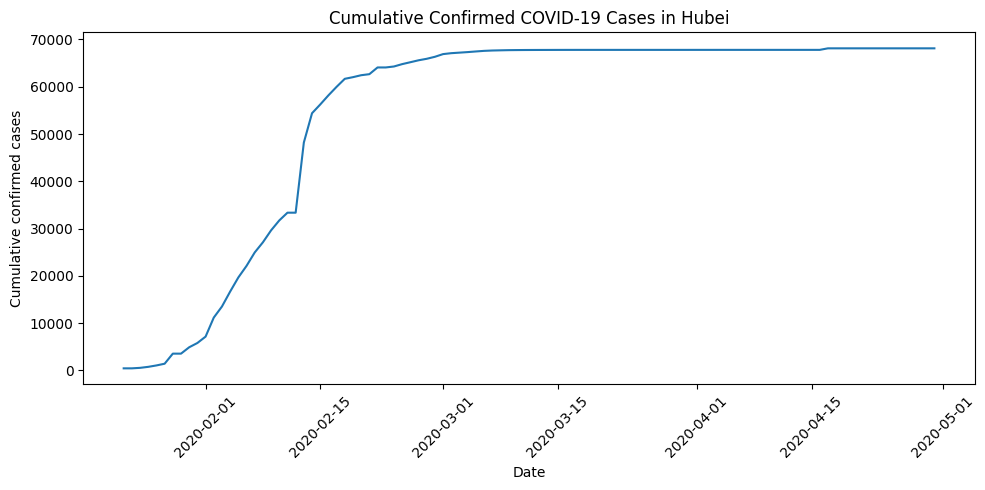

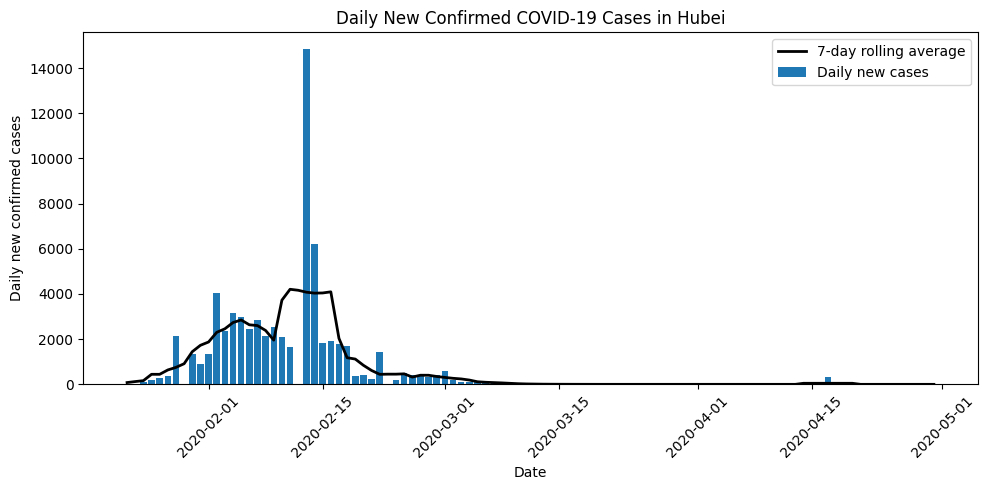

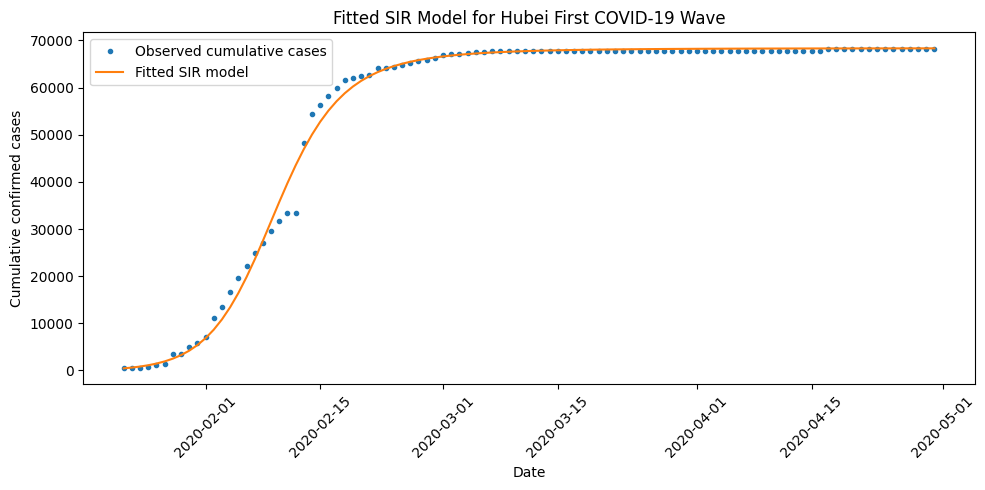

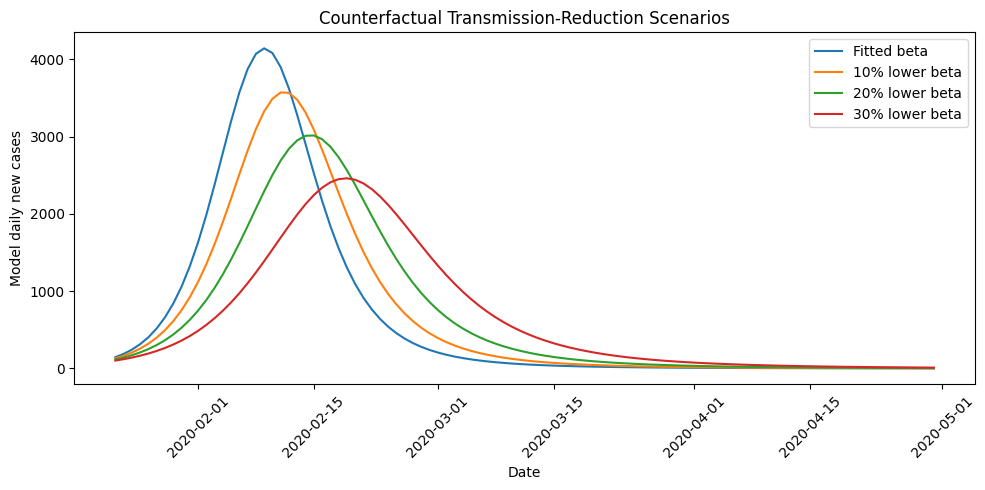

In [16]:
plt.figure(figsize=(10, 5))
plt.plot(df["date"], observed_cumulative)
plt.xlabel("Date")
plt.ylabel("Cumulative confirmed cases")
plt.title("Cumulative Confirmed COVID-19 Cases in Hubei")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(figure_dir / "hubei_cumulative_cases.png", dpi=300)
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(df["date"], df["new_cases"], label="Daily new cases")
plt.plot(df["date"], df["new_cases"].rolling(7, center=True, min_periods=1).mean(), color="black", linewidth=2, label="7-day rolling average")
plt.xlabel("Date")
plt.ylabel("Daily new confirmed cases")
plt.title("Daily New Confirmed COVID-19 Cases in Hubei")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig(figure_dir / "hubei_daily_cases.png", dpi=300)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(df["date"], observed_cumulative, "o", markersize=3, label="Observed cumulative cases")
plt.plot(df["date"], fitted_cumulative, label="Fitted SIR model")
plt.xlabel("Date")
plt.ylabel("Cumulative confirmed cases")
plt.title("Fitted SIR Model for Hubei First COVID-19 Wave")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig(figure_dir / "hubei_sir_fit.png", dpi=300)
plt.show()

plt.figure(figsize=(10, 5))
for label, daily_new_cases in counterfactual_curves.items():
    plt.plot(df["date"], daily_new_cases, label=label)
plt.xlabel("Date")
plt.ylabel("Model daily new cases")
plt.title("Counterfactual Transmission-Reduction Scenarios")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig(figure_dir / "hubei_counterfactual_scenarios.png", dpi=300)
plt.show()


In [17]:
parameters_df = pd.DataFrame([{
    "beta": beta_fit,
    "gamma": gamma_fit,
    "R0_beta_over_gamma": beta_fit / gamma_fit,
    "N_eff": N_eff_fit
}])

df.to_csv(result_dir / "hubei_first_wave_data.csv", index=False)
parameters_df.to_csv(result_dir / "hubei_sir_fit_parameters.csv", index=False)
results_df.to_csv(result_dir / "hubei_sir_scenario_results.csv", index=False)

parameters_df, results_df


(      beta     gamma  R0_beta_over_gamma         N_eff
 0  0.32884  0.065299            5.035887  68809.280002,
          Scenario      Beta  Peak daily cases  Peak date  \
 0     Fitted beta  0.328840       4141.213135 2020-02-09   
 1  10% lower beta  0.295956       3570.995457 2020-02-11   
 2  20% lower beta  0.263072       3014.090000 2020-02-15   
 3  30% lower beta  0.230188       2459.837362 2020-02-19   
 
    Final cumulative cases  
 0            68332.455809  
 1            68001.180940  
 2            67421.063758  
 3            66369.143732  )